In [1]:
# Import libraries for reading data, preprocessing text, TF-IDF, SVD, plotting, and saving outputs.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import html
import contractions
import nltk
import os

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/brittanyuy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/brittanyuy/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/brittanyuy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/brittanyuy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
# Load the balanced descriptions-only dataset.
# Qucumber asked for SVD on this file, not balanced_bgg.csv.

balanced_desc_df = pd.read_csv("../../data/new/balanced_desc_only.csv")

print("Balanced desc-only shape:", balanced_desc_df.shape)
print("Columns:", balanced_desc_df.columns.tolist())

balanced_desc_df.head()

Balanced desc-only shape: (8193, 3)
Columns: ['Unnamed: 0', 'name', 'description_x']


,Unnamed: 0,name,description_x
0,0,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...
1,1,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ..."
2,2,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...
3,3,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...
4,4,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ..."


In [3]:
# Clean the name and description_x columns.
# This removes rows with missing or empty descriptions.

balanced_desc_df = balanced_desc_df.dropna(subset=["name", "description_x"]).copy()

balanced_desc_df["name"] = balanced_desc_df["name"].astype(str)
balanced_desc_df["description_x"] = balanced_desc_df["description_x"].astype(str)

balanced_desc_df = balanced_desc_df[
    balanced_desc_df["description_x"].str.strip() != ""
].copy()

print("Cleaned balanced desc-only shape:", balanced_desc_df.shape)

balanced_desc_df.head()

Cleaned balanced desc-only shape: (8193, 3)


,Unnamed: 0,name,description_x
0,0,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...
1,1,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ..."
2,2,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...
3,3,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...
4,4,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ..."


In [4]:
# This is the best preprocessing setup from the previous SVD experiments.
# It keeps only alphabetic words after cleaning.

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_nltk_alpha_only(text):
    # Fix HTML symbols like &quot;
    text = html.unescape(str(text))

    # Expand contractions like don't -> do not
    text = contractions.fix(text)

    # Split text into words
    tokens = word_tokenize(text.lower())

    # Remove stopwords, remove non-alphabetic tokens, remove short words, and lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word.isalpha() and word not in stop_words and len(word) > 2
    ]

    return " ".join(tokens)

In [5]:
# Apply preprocessing to all descriptions in balanced_desc_only.csv.

descs = balanced_desc_df["description_x"].astype(str).tolist()

processed_corpus_alpha = [
    preprocess_nltk_alpha_only(doc)
    for doc in descs
]

print("Number of processed descriptions:", len(processed_corpus_alpha))

processed_corpus_alpha[:3]

Number of processed descriptions: 8193


['pressman take classic game put exciting console plus even player play time turn wheel pick rock paper scissors flip reveal shield score point player beat special game hub included play',
 'show good loser show real loser oneupmanship satirical board game player struggle money power ego winner first player earn mean possible playing stock market building skyscraper gambling collecting trophy',
 'pressman take classic game put exciting console plus even player play time turn wheel pick rock paper scissors flip reveal shield score point player beat special game hub included play']

In [6]:
# Convert the cleaned descriptions into TF-IDF vectors.
# Then fit TruncatedSVD with max components capped at 5000.

tfidf_vectorizer_desc = TfidfVectorizer(
    token_pattern=r"\w+",
    lowercase=True,
    min_df=5,
)

X_tfidf_desc = tfidf_vectorizer_desc.fit_transform(processed_corpus_alpha)

print("TF-IDF shape:", X_tfidf_desc.shape)

max_components = min(
    5000,
    X_tfidf_desc.shape[0] - 1,
    X_tfidf_desc.shape[1] - 1
)

svd_desc = TruncatedSVD(
    n_components=max_components,
    random_state=42
)

svd_desc.fit(X_tfidf_desc)

print("SVD fitted with components:", max_components)

TF-IDF shape: (8193, 6414)
SVD fitted with components: 5000


In [7]:
# Find the smallest number of singular values needed to reach 90% explained variance.

energy_desc = svd_desc.singular_values_**2
energy_ratio_desc = energy_desc / energy_desc.sum()
energy_ratio_cumsum_desc = energy_ratio_desc.cumsum()

desc_svs = None

for i in range(len(energy_ratio_cumsum_desc)):
    if energy_ratio_cumsum_desc[i] >= 0.90:
        desc_svs = i + 1
        print(f"Explained variance at {desc_svs} SVs: {energy_ratio_cumsum_desc[i]:.2f}")
        break

if desc_svs is None:
    print(f"Did not reach 0.90. Max explained variance: {energy_ratio_cumsum_desc[-1]:.2f}")

Explained variance at 718 SVs: 0.90


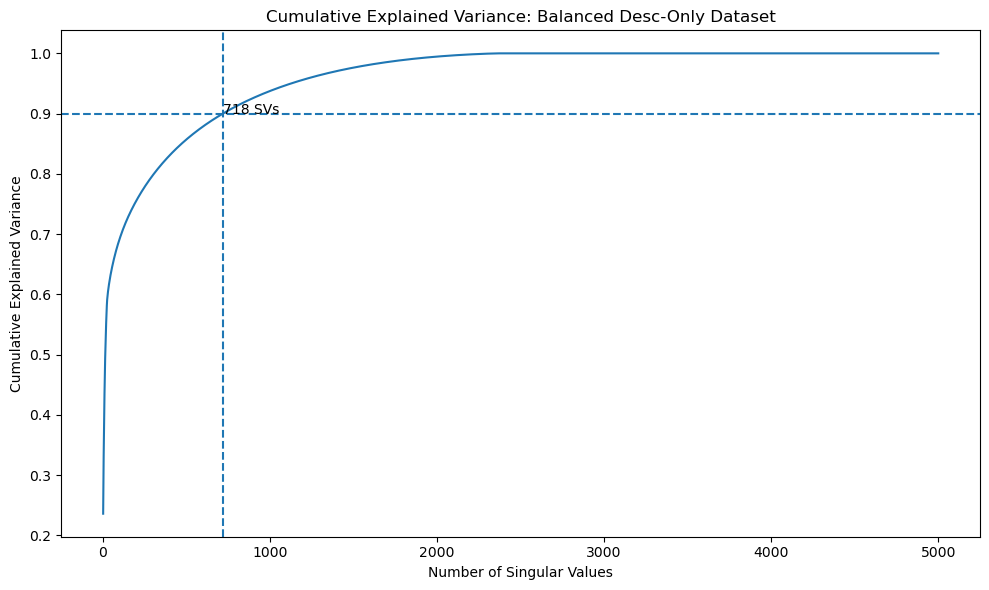

In [8]:
# Plot cumulative explained variance and mark the 90% threshold.

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(energy_ratio_cumsum_desc) + 1),
    energy_ratio_cumsum_desc
)

plt.axhline(0.90, linestyle="--")

if desc_svs is not None:
    plt.axvline(desc_svs, linestyle="--")
    plt.text(desc_svs, 0.90, f"{desc_svs} SVs")

plt.title("Cumulative Explained Variance: Balanced Desc-Only Dataset")
plt.xlabel("Number of Singular Values")
plt.ylabel("Cumulative Explained Variance")
plt.tight_layout()
plt.show()

In [9]:
# Create the final SVD table using only the threshold SVs.
# This file contains name, description_x, and the SVD semantic vectors.

final_n_svs = desc_svs

X_svd_desc_final = svd_desc.transform(X_tfidf_desc)[:, :final_n_svs]

svd_desc_table = pd.DataFrame(
    X_svd_desc_final,
    columns=[f"SV_{i+1}" for i in range(final_n_svs)]
)

svd_desc_table = pd.concat(
    [
        balanced_desc_df[["name", "description_x"]].reset_index(drop=True),
        svd_desc_table.reset_index(drop=True)
    ],
    axis=1
)

svd_desc_table.to_csv("balanced_desc_only_svd_table.csv", index=False)

print("Balanced desc-only SVD table shape:", svd_desc_table.shape)

svd_desc_table.head()

Balanced desc-only SVD table shape: (8193, 720)


,name,description_x,SV_1,SV_2,SV_3,SV_4,SV_5,SV_6,SV_7,SV_8,...,SV_709,SV_710,SV_711,SV_712,SV_713,SV_714,SV_715,SV_716,SV_717,SV_718
0,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,0.049594,0.259442,-0.325072,0.124995,0.369973,0.176221,0.000246,0.007431,...,0.000059,-0.000132,-0.000136,0.000233,-0.000074,-0.000063,0.00020,-0.000019,-0.000068,-0.000133
1,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...",0.039517,0.165516,-0.154951,0.029922,-0.183830,-0.024334,-0.456220,0.816265,...,0.000063,0.000066,-0.000041,0.000069,0.000169,-0.000038,0.00034,-0.000054,0.000117,-0.000245
2,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,0.049594,0.259442,-0.325072,0.124995,0.369973,0.176221,0.000246,0.007431,...,0.000059,-0.000132,-0.000136,0.000233,-0.000074,-0.000063,0.00020,-0.000019,-0.000068,-0.000133
3,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,0.049594,0.259442,-0.325072,0.124995,0.369973,0.176221,0.000246,0.007431,...,0.000059,-0.000132,-0.000136,0.000233,-0.000074,-0.000063,0.00020,-0.000019,-0.000068,-0.000133
4,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...",0.039517,0.165516,-0.154951,0.029922,-0.183830,-0.024334,-0.456220,0.816265,...,0.000063,0.000066,-0.000041,0.000069,0.000169,-0.000038,0.00034,-0.000054,0.000117,-0.000245


In [10]:
# Check the CSV file size before pushing to GitHub.

file_name = "balanced_desc_only_svd_table.csv"

if os.path.exists(file_name):
    file_size_mb = os.path.getsize(file_name) / (1024 * 1024)
    print(f"{file_name}: {file_size_mb:.2f} MB")
else:
    print(f"{file_name} not found.")

balanced_desc_only_svd_table.csv: 133.33 MB


## Balanced Desc-Only Dataset SVD Result

Using `balanced_desc_only.csv`, the descriptions were preprocessed using NLTK alphabetic-only preprocessing. The cleaned text was vectorized using TF-IDF with `min_df=5`, then reduced using TruncatedSVD with a maximum of 5,000 components.

The final number of retained singular values was selected based on the point where cumulative explained variance reached 0.90.